# ДЗ №5. TIGER-like архитектура для рекомендаций

Общая информация  

Дата выдачи: 25 мая 2026

Дедлайн: 10 июня 2026 23:59 MSK


В этом задании мы соберем упрощенный generative retrieval pipeline по мотивам [**TIGER**](https://proceedings.neurips.cc/paper_files/paper/2023/file/20dcab0f14046a5c6b02b61da9f13229-Paper-Conference.pdf):

1. Возьмем датасет **KION**.
2. Построим для айтемов **semantic ids** через **RQ-VAE**.
3. Поверх semantic ids обучим **tiger-like** next-token recommender.
4. Посчитаем метрики на **настоящих `item_id`**, а не на токенах semantic id.
5. Сравним результат с `MostPop` и `SASRec-like` baseline.
6. Отдельно проверим, что происходит, если semantic id обучаются **без уникализирующего suffix/id**, а затем декодируются обратно в item разными способами.

В отличие от классических retrieval-моделей, здесь модель не ранжирует весь каталог напрямую, а **генерирует код следующего айтема**. Поэтому в этом ДЗ важно аккуратно разделять:

- качество самих semantic ids;
- качество generative модели по semantic ids;
- качество итоговых рекомендаций после обратного декодинга в реальные `item_id`.


В этом задании следующая разбалловка:

1. Обучение и анализ semantic ids через `RQ-VAE` - **3 балла**
2. Обучение `tiger-like` next-token модели - **3 балла**
3. Сравнение с `MostPop` и `SASRec-like` - **2 балла**
4. Эксперимент с неуникальными semantic ids и разными стратегиями декодинга - **2 балла**

Соответственно, максимум можно набрать **10 баллов**.


## Короткая теория

### 1. Semantic IDs

Проблема обычных `item_id` в том, что они, как правило, **не несут семантики**: два похожих фильма имеют совершенно независимые идентификаторы.  
Идея semantic ids состоит в том, чтобы сопоставить каждому айтему **короткую дискретную последовательность токенов**, где близкие по смыслу айтемы имеют похожие коды.

Для этого удобно взять фиксированные item-embeddings по контенту и затем **квантовать** их через `RQ-VAE`:

- encoder переводит эмбеддинг в другое скрытое представление;
- residual quantization по нескольким codebook-уровням превращает в последовательность дискретных кодов;
- decoder пытается восстановить исходный embedding;
- дополнительные регуляризаторы позволяют контролировать загрузку codebook-ов, коллизии и энтропию.

### 2. TIGER-like generative retrieval

В статье TIGER recommendation рассматривается как **autoregressive generation** semantic id следующего айтема.  
История пользователя кодируется как последовательность токенов прошлых semantic ids, а модель предсказывает токены следующего айтема.

Упрощенно это выглядит так:

- у айтема есть semantic id, например `[c1, c2, c3, c4]`;
- история пользователя превращается в длинную token-sequence;
- decoder-only Transformer предсказывает следующий токен;
- после генерации semantic id он декодируется обратно в реальный `item_id`.

### 3. Зачем нужен уникализирующий suffix

Если несколько айтемов попадают в один и тот же semantic bucket, возникает **коллизия**.  
Один способ справиться с этим - добавить к semantic id дополнительный уникализирующий suffix.  
Другой путь - оставить id чисто семантическим, а потом восстанавливать `item_id` через отдельный mapping внутри bucket-а. Именно это вы исследуете в последней части ДЗ.


[Ссылка](https://proceedings.neurips.cc/paper_files/paper/2023/file/20dcab0f14046a5c6b02b61da9f13229-Paper-Conference.pdf) на работу по Semantic-ids и TIGER:




In [3]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn torch tqdm sentencepiece


In [4]:
import math
import random
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


## 0. Загрузка данных

Работаем с KION-датасетом из соревнования:

https://ods.ai/competitions/competition-recsys-21/data

Нужны файлы:

- `interactions.csv`
- `items.csv`
- `users.csv`

Ноутбук ищет их рядом с собой, уровнем выше или на два уровня выше.


In [5]:
def find_file(candidates: List[str]) -> Optional[Path]:
    search_roots = [Path("."), Path(".."), Path("../.."), Path("/mnt/data")]
    for root in search_roots:
        for name in candidates:
            path = root / name
            if path.exists():
                return path.resolve()
    return None


interactions_path = find_file(["/kaggle/input/datasets/vasilisadan18/hw-5-recsys/interactions.csv"])
items_path = find_file(["/kaggle/input/datasets/vasilisadan18/hw-5-recsys/items.csv"])
users_path = find_file(["/kaggle/input/datasets/vasilisadan18/hw-5-recsys/users.csv"])

print("interactions_path =", interactions_path)
print("items_path        =", items_path)
print("users_path        =", users_path)


interactions_path = /kaggle/input/datasets/vasilisadan18/hw-5-recsys/interactions.csv
items_path        = /kaggle/input/datasets/vasilisadan18/hw-5-recsys/items.csv
users_path        = /kaggle/input/datasets/vasilisadan18/hw-5-recsys/users.csv


In [6]:
assert interactions_path is not None, "Не найден interactions.csv"
assert items_path is not None, "Не найден items.csv"
assert users_path is not None, "Не найден users.csv"

interactions = pd.read_csv(interactions_path)
items = pd.read_csv(items_path)
users = pd.read_csv(users_path)

print(interactions.shape, items.shape, users.shape)
interactions.head()


(5476251, 5) (15963, 14) (840197, 5)


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


## 1. Подготовка выборки

Чтобы не делать ДЗ неподъемным, возьмем **сэмпл активных пользователей и популярных айтемов**.  
При желании вы можете изменить размеры выборки, но в отчете обязательно укажите, какой сэмпл использовали.


In [36]:
RANDOM_STATE = 42
SAMPLE_USERS = 15000
SAMPLE_ITEMS = 20000
MIN_USER_INTERACTIONS = 5
MAX_SEQ_LEN = 50
TOP_K = 10

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
TARGET_COL = "item_id"
USER_COL = "user_id"
TIME_COL = "last_watch_dt" if "last_watch_dt" in interactions.columns else "watched_pct"


In [9]:
interactions = interactions.copy()

if "last_watch_dt" in interactions.columns:
    interactions["last_watch_dt"] = pd.to_datetime(interactions["last_watch_dt"])
    sort_cols = [USER_COL, "last_watch_dt"]
else:
    sort_cols = [USER_COL]

if "total_dur" in interactions.columns:
    interactions["total_dur"] = interactions["total_dur"].fillna(0)

user_activity = interactions[USER_COL].value_counts()
item_popularity = interactions[TARGET_COL].value_counts()

selected_users = user_activity.head(SAMPLE_USERS).index
selected_items = item_popularity.head(SAMPLE_ITEMS).index

df = interactions[
    interactions[USER_COL].isin(selected_users) &
    interactions[TARGET_COL].isin(selected_items)
].copy()

df = df.sort_values(sort_cols).reset_index(drop=True)
df = df[df.groupby(USER_COL)[TARGET_COL].transform("size") >= MIN_USER_INTERACTIONS].copy()

print(df.shape)
df.head()


(995585, 5)


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,2,7571,2021-05-20,6151,100.0
1,2,11577,2021-05-21,4974,98.0
2,2,16166,2021-05-21,5980,95.0
3,2,8936,2021-05-29,18,1.0
4,2,4436,2021-05-29,2618,30.0


Сделайте split по пользователям в стиле leave-last-out:

- `train`: вся история кроме двух последних событий пользователя;
- `valid`: предпоследний айтем;
- `test`: последний айтем.

Если хотите, можете использовать другой аккуратный temporal split, но тогда явно опишите его в отчете.


In [10]:
def leave_last_two_out(data: pd.DataFrame, user_col: str, item_col: str, sort_cols: List[str]):
    data = data.sort_values(sort_cols).copy()
    data["_row_num"] = data.groupby(user_col).cumcount()
    data["_user_len"] = data.groupby(user_col)[item_col].transform("size")

    train = data[data["_row_num"] < data["_user_len"] - 2].copy()
    valid = data[data["_row_num"] == data["_user_len"] - 2].copy()
    test = data[data["_row_num"] == data["_user_len"] - 1].copy()

    return (
        train.drop(columns=["_row_num", "_user_len"]),
        valid.drop(columns=["_row_num", "_user_len"]),
        test.drop(columns=["_row_num", "_user_len"]),
    )


train_df, valid_df, test_df = leave_last_two_out(df, USER_COL, TARGET_COL, sort_cols)

print(train_df.shape, valid_df.shape, test_df.shape)


(965585, 5) (15000, 5) (15000, 5)


In [11]:
train_sequences = (
    train_df
    .sort_values(sort_cols)
    .groupby(USER_COL)[TARGET_COL]
    .apply(list)
    .to_dict()
)

valid_targets = dict(zip(valid_df[USER_COL], valid_df[TARGET_COL]))
test_targets = dict(zip(test_df[USER_COL], test_df[TARGET_COL]))

eval_users = sorted(set(test_targets) & set(train_sequences))
len(eval_users)


15000

## 2. Метрики

Мы сравниваем модели уже на **реальных item_id**.  
Реализуйте (или переиспользуйте реализации из предыдущих ДЗ) как минимум:

- `Recall@K`
- `NDCG@K`
- `MRR@K`

Можно дополнительно посчитать `HitRate@K`, `Coverage@K`, `Novelty@K`.


In [12]:
def recall_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    scores = []
    for user_id, target_item in target.items():
        user_recs = recs.get(user_id, [])[:k]
        scores.append(1.0 if target_item in user_recs else 0.0)
    return float(np.mean(scores)) if scores else 0.0


def ndcg_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    scores = []
    for user_id, target_item in target.items():
        user_recs = recs.get(user_id, [])[:k]
        if target_item in user_recs:
            rank = user_recs.index(target_item) + 1
            scores.append(1.0 / math.log2(rank + 1))
        else:
            scores.append(0.0)
    return float(np.mean(scores)) if scores else 0.0


def mrr_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    scores = []
    for user_id, target_item in target.items():
        user_recs = recs.get(user_id, [])[:k]
        if target_item in user_recs:
            rank = user_recs.index(target_item) + 1
            scores.append(1.0 / rank)
        else:
            scores.append(0.0)
    return float(np.mean(scores)) if scores else 0.0


def evaluate_recommendations(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> pd.DataFrame:
    return pd.DataFrame(
        {
            f"Recall@{k}": [recall_at_k(recs, target, k)],
            f"NDCG@{k}": [ndcg_at_k(recs, target, k)],
            f"MRR@{k}": [mrr_at_k(recs, target, k)],
        },
        index=["score"],
    )


## I. Semantic IDs через RQ-VAE (3 балла)

В этой части нужно:

1. Построить фиксированные item-embeddings по метаданным айтемов.
2. Обучить `RQ-VAE`, получив многотокенный semantic id.
3. Посчитать и визуализировать метрики качества semantic ids.

Обязательно покажите графики обучения хотя бы по:

- reconstruction loss;
- доле коллизий;
- энтропии использования кодов;
- average bucket size или effective codebook usage.

Дополнительно приветствуются:

- доля неиспользуемых кодов;

Реализацию вы можете взять отсюда [https://github.com/EdoardoBotta/RQ-VAE-Recommender](https://github.com/EdoardoBotta/RQ-VAE-Recommender)


Для простоты можно собрать content features из `title`, `genres`, `countries`, `release_year`, других доступных полей.  
Необязательно делать сильный content encoder: в этой работе главное не качество текстовой модели, а корректный пайплайн `semantic ids -> generative retrieval`.

Ниже используется TF-IDF, но вы можете заменить эмбеддер на любую хорошую языковую модель


In [13]:
def split_tokens(x) -> List[str]:
    if pd.isna(x):
        return []
    text = str(x)
    for sep in [",", "|", "/"]:
        if sep in text:
            return [part.strip() for part in text.split(sep) if part.strip()]
    return [text.strip()] if text.strip() else []


items_work = items[items[TARGET_COL].isin(pd.Index(df[TARGET_COL].unique()))].copy()
items_work["title"] = items_work.get("title", pd.Series("", index=items_work.index)).fillna("")
items_work["genres_text"] = items_work.get("genres", pd.Series("", index=items_work.index)).fillna("")
items_work["countries_text"] = items_work.get("countries", pd.Series("", index=items_work.index)).fillna("")
items_work["release_year_num"] = pd.to_numeric(
    items_work.get("release_year", pd.Series(np.nan, index=items_work.index)),
    errors="coerce",
).fillna(0)

items_work["content_text"] = (
    items_work["title"].astype(str) + " " +
    items_work["genres_text"].astype(str) + " " +
    items_work["countries_text"].astype(str)
)

items_work = items_work.drop_duplicates(subset=[TARGET_COL]).reset_index(drop=True)
items_work.head()


,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,genres_text,countries_text,release_year_num,content_text
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ...","драмы, зарубежные, детективы, мелодрамы",Испания,2002.0,"Поговори с ней драмы, зарубежные, детективы, м..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео...","зарубежные, приключения, комедии",США,2014.0,"Голые перцы зарубежные, приключения, комедии США"
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг...","криминал, зарубежные, триллеры, боевики, комедии",Канада,2011.0,"Тактическая сила криминал, зарубежные, триллер..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю...","драмы, зарубежные, мелодрамы",Великобритания,2015.0,"45 лет драмы, зарубежные, мелодрамы Великобрит..."
4,1468,film,Марья-искусница,NaN,1960.0,"фильмы, сказки, приключения, советские, семейн...",СССР,NaN,6.0,NaN,Александр Роу,"Александр Баранов, Александр Хвыля, Анатолий К...",Два прославленных советских сказочника – писат...,"Марья-искусница, 1960, СССР, преодоление, труд...","фильмы, сказки, приключения, советские, семейн...",СССР,1960.0,"Марья-искусница фильмы, сказки, приключения, с..."


In [14]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
text_features = vectorizer.fit_transform(items_work["content_text"])

svd = TruncatedSVD(n_components=128, random_state=RANDOM_STATE)
text_dense = svd.fit_transform(text_features)

num_features = items_work[["release_year_num"]].to_numpy(dtype=np.float32)
num_features = StandardScaler().fit_transform(num_features)

item_content_matrix = np.concatenate([text_dense, num_features], axis=1).astype(np.float32)
item_ids = items_work[TARGET_COL].tolist()

print(item_content_matrix.shape)


(13929, 129)


In [15]:
@dataclass
class RQVAEConfig:
    input_dim: int
    hidden_dim: int = 256
    latent_dim: int = 64
    num_codebooks: int = 4
    codebook_size: int = 64
    commitment_weight: float = 0.25
    entropy_weight: float = 0.0

class RQVAE(nn.Module):

    def __init__(self, config: RQVAEConfig):
        super().__init__()
        self.config = config
        self.input_dim = config.input_dim
        self.hidden_dim = config.hidden_dim
        self.latent_dim = config.latent_dim
        self.num_codebooks = config.num_codebooks
        self.codebook_size = config.codebook_size
        self.commitment_weight = config.commitment_weight
        self.entropy_weight = config.entropy_weight

        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.latent_dim),
        )

        self.codebooks = nn.ParameterList(
            [
                nn.Parameter(torch.randn(self.codebook_size, self.latent_dim))
                for _ in range(self.num_codebooks)
            ]
        )
        for cb in self.codebooks:
            nn.init.xavier_uniform_(cb)

        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.input_dim),
        )

    def encode(self, x: torch.Tensor):
        return self.encoder(x)

    def quantize(self, z_e: torch.Tensor):
        residual = z_e
        z_q = torch.zeros_like(z_e)
        codes = []
        vq_loss = 0.0

        for cb_idx, cb in enumerate(self.codebooks):
            norm_residual = F.normalize(residual, p=2, dim=-1)
            norm_cb = F.normalize(cb, p=2, dim=-1)

            dist = torch.cdist(norm_residual, norm_cb)
            idx = torch.argmin(dist, dim=1)
            codes.append(idx)

            z_q_i = cb[idx]

            if self.training:
                with torch.no_grad():
                    unreferenced = torch.ones(self.codebook_size, dtype=torch.bool, device=z_e.device)
                    unreferenced[idx] = False
                    n_unreferenced = unreferenced.sum().item()
                    if n_unreferenced > 0:
                        perm = torch.randperm(residual.size(0), device=z_e.device)
                        samples = residual[perm[:n_unreferenced]]
                        if samples.size(0) == n_unreferenced:
                            cb.data[unreferenced] = samples

            loss_codebook = F.mse_loss(z_q_i, residual.detach())
            loss_commitment = F.mse_loss(z_q_i.detach(), residual)
            vq_loss += loss_codebook + self.commitment_weight * loss_commitment

            z_q_i_ste = residual + (z_q_i - residual).detach()
            z_q = z_q + z_q_i_ste
            residual = (residual - z_q_i).detach()

        return z_q, torch.stack(codes, dim=1), vq_loss / self.num_codebooks

    def decode(self, z_q: torch.Tensor):
        return self.decoder(z_q)

    def forward(self, x: torch.Tensor):
        z_e = self.encode(x)
        z_q, codes, vq_loss = self.quantize(z_e)
        x_recon = self.decode(z_q)
        recon_loss = F.mse_loss(x_recon, x)
        total_loss = recon_loss + vq_loss
        return total_loss, recon_loss, vq_loss, codes


def semantic_collision_rate(codes: np.ndarray) -> float:
    unique_codes = {tuple(row.tolist()) for row in codes}
    return 1.0 - len(unique_codes) / len(codes)


def average_bucket_size(codes: np.ndarray) -> float:
    buckets = Counter(map(tuple, codes.tolist()))
    return float(np.mean(list(buckets.values())))


def codebook_entropy(codes_2d: np.ndarray, codebook_size: int) -> List[float]:
    entropies = []
    for level in range(codes_2d.shape[1]):
        counts = np.bincount(codes_2d[:, level], minlength=codebook_size).astype(
            np.float64
        )
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropies.append(float(-(probs * np.log(probs + 1e-12)).sum()))
    return entropies

In [16]:
def semantic_collision_rate(codes: np.ndarray) -> float:
    unique_codes = {tuple(row.tolist()) for row in codes}
    return 1.0 - len(unique_codes) / len(codes)


def average_bucket_size(codes: np.ndarray) -> float:
    buckets = Counter(map(tuple, codes.tolist()))
    return float(np.mean(list(buckets.values())))


def codebook_entropy(codes_2d: np.ndarray, codebook_size: int) -> List[float]:
    entropies = []
    for level in range(codes_2d.shape[1]):
        counts = np.bincount(codes_2d[:, level], minlength=codebook_size).astype(np.float64)
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropies.append(float(-(probs * np.log(probs + 1e-12)).sum()))
    return entropies


In [17]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

In [18]:
rq_config = RQVAEConfig(input_dim=item_content_matrix.shape[1])
rqvae = RQVAE(rq_config).to(DEVICE)
batch_size = 256
dataset = torch.utils.data.TensorDataset(
    torch.tensor(item_content_matrix, dtype=torch.float32)
)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

rq_config = RQVAEConfig(input_dim=item_content_matrix.shape[1])
rqvae = RQVAE(rq_config).to(DEVICE)

num_epochs = 30
optimizer = torch.optim.Adam(rqvae.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=1e-5
)

history = {
    "total_loss": [],
    "recon_loss": [],
    "vq_loss": [],
    "collision_rate": [],
    "avg_bucket_size": [],
    "entropy_per_level": [],
    "unused_codes_per_level": [],
}

for epoch in range(num_epochs):
    rqvae.train()
    epoch_total_loss = 0.0
    epoch_recon_loss = 0.0
    epoch_vq_loss = 0.0
    all_codes = []

    for batch in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        x = batch[0].to(DEVICE)
        optimizer.zero_grad()
        total_loss, recon_loss, vq_loss, codes = rqvae(x)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(rqvae.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_total_loss += total_loss.item() * x.size(0)
        epoch_recon_loss += recon_loss.item() * x.size(0)
        epoch_vq_loss += vq_loss.item() * x.size(0)
        all_codes.append(codes.detach().cpu().numpy())

    n_samples = len(dataset)
    history["total_loss"].append(epoch_total_loss / n_samples)
    history["recon_loss"].append(epoch_recon_loss / n_samples)
    history["vq_loss"].append(epoch_vq_loss / n_samples)

    all_codes = np.concatenate(all_codes, axis=0)
    collision = semantic_collision_rate(all_codes)
    avg_bucket = average_bucket_size(all_codes)
    entropies = codebook_entropy(all_codes, rq_config.codebook_size)
    unused_per_level = []
    for level in range(rq_config.num_codebooks):
        unique = len(np.unique(all_codes[:, level]))
        unused = rq_config.codebook_size - unique
        unused_per_level.append(unused)

    history["collision_rate"].append(collision)
    history["avg_bucket_size"].append(avg_bucket)
    history["entropy_per_level"].append(entropies)
    history["unused_codes_per_level"].append(unused_per_level)

    print(
        f"Epoch {epoch+1}: loss={history['total_loss'][-1]:.4f}, recon={history['recon_loss'][-1]:.4f}, "
        f"collision={collision:.3f}, avg_bucket={avg_bucket:.2f}"
    )
    scheduler.step()

Epoch 1/30:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 1: loss=0.0166, recon=0.0105, collision=0.111, avg_bucket=1.12


Epoch 2/30:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 2: loss=0.2421, recon=0.0092, collision=0.071, avg_bucket=1.08


Epoch 3/30:   0%|          | 0/55 [00:00<?, ?it/s]

...

Epoch 28: loss=0.1700, recon=0.0101, collision=0.111, avg_bucket=1.12


Epoch 29/30:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 29: loss=0.2086, recon=0.0087, collision=0.120, avg_bucket=1.14


Epoch 30/30:   0%|          | 0/55 [00:00<?, ?it/s]

Epoch 30: loss=0.0676, recon=0.0082, collision=0.135, avg_bucket=1.16


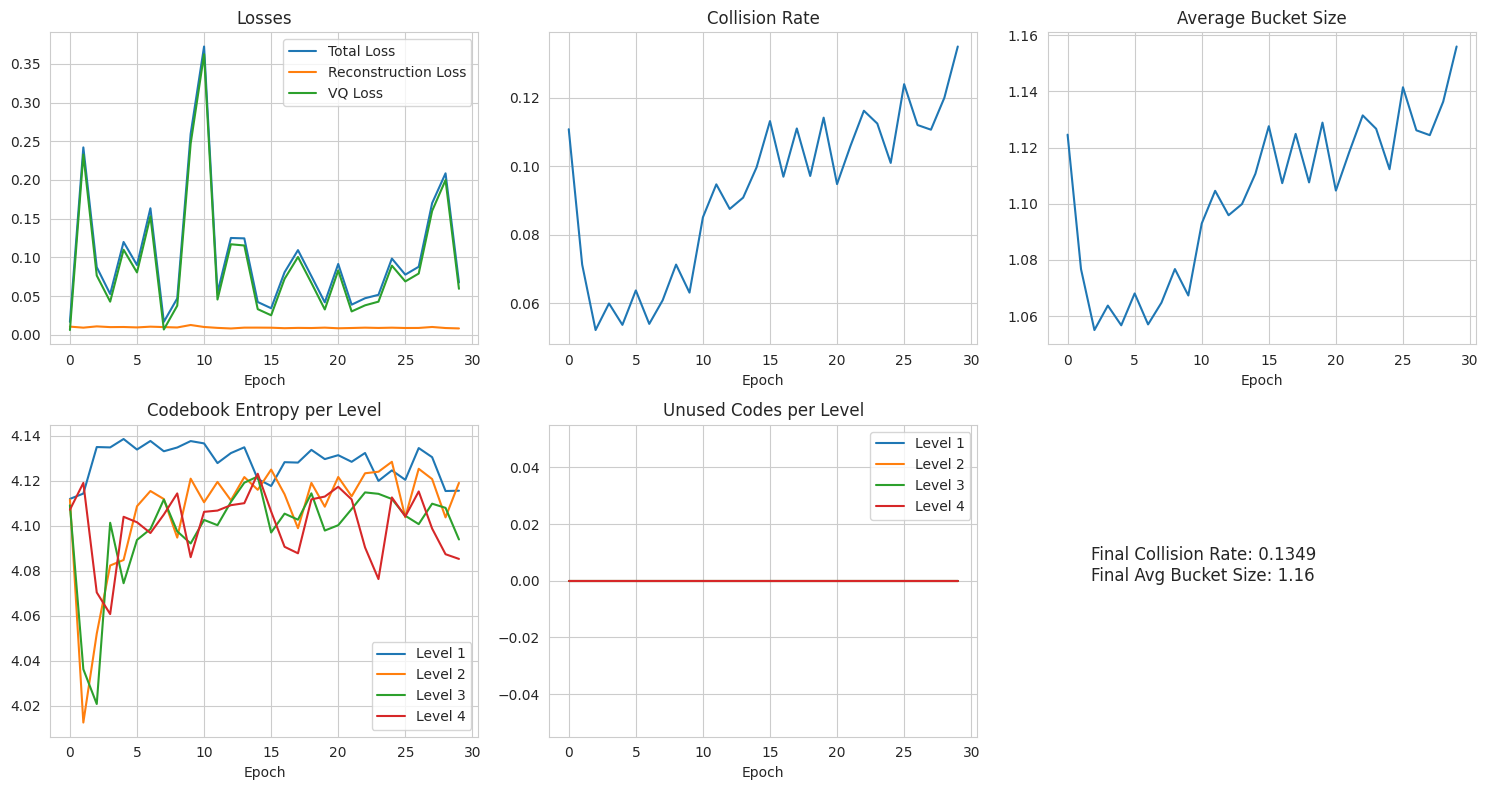

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].plot(history["total_loss"], label="Total Loss")
axes[0,0].plot(history["recon_loss"], label="Reconstruction Loss")
axes[0,0].plot(history["vq_loss"], label="VQ Loss")
axes[0,0].set_title("Losses")
axes[0,0].legend()
axes[0,0].set_xlabel("Epoch")

axes[0,1].plot(history["collision_rate"])
axes[0,1].set_title("Collision Rate")
axes[0,1].set_xlabel("Epoch")

axes[0,2].plot(history["avg_bucket_size"])
axes[0,2].set_title("Average Bucket Size")
axes[0,2].set_xlabel("Epoch")


entropy_matrix = np.array([e for e in history["entropy_per_level"]])
for level in range(entropy_matrix.shape[1]):
    axes[1,0].plot(entropy_matrix[:, level], label=f"Level {level+1}")
axes[1,0].set_title("Codebook Entropy per Level")
axes[1,0].legend()
axes[1,0].set_xlabel("Epoch")

unused_matrix = np.array([u for u in history["unused_codes_per_level"]])
for level in range(unused_matrix.shape[1]):
    axes[1,1].plot(unused_matrix[:, level], label=f"Level {level+1}")
axes[1,1].set_title("Unused Codes per Level")
axes[1,1].legend()
axes[1,1].set_xlabel("Epoch")
axes[1,2].text(0.1, 0.5, f"Final Collision Rate: {history['collision_rate'][-1]:.4f}\n"
                         f"Final Avg Bucket Size: {history['avg_bucket_size'][-1]:.2f}",
               fontsize=12, transform=axes[1,2].transAxes)
axes[1,2].axis("off")

plt.tight_layout()
plt.show()

In [20]:
rqvae.eval()
with torch.no_grad():
    x_tensor = torch.tensor(item_content_matrix, dtype=torch.float32).to(DEVICE)
    _, _, _, codes = rqvae(x_tensor)
    semantic_tokens = codes.cpu().numpy()

item_semantic = pd.DataFrame(
    {
        "item_id": item_ids,
        "semantic_tokens": [tuple(row) for row in semantic_tokens],
    }
)

bucket_counter = defaultdict(int)
unique_suffix = []
for tokens in item_semantic["semantic_tokens"]:
    bucket_counter[tokens] += 1
    unique_suffix.append(bucket_counter[tokens] - 1)

item_semantic["semantic_tokens_unique"] = [
    tuple(list(tokens) + [suffix])
    for tokens, suffix in zip(item_semantic["semantic_tokens"], unique_suffix)
]

print(item_semantic.head())

   item_id   semantic_tokens semantic_tokens_unique
0    10711   (31, 18, 8, 40)     (31, 18, 8, 40, 0)
1     2508   (59, 40, 23, 7)     (59, 40, 23, 7, 0)
2    10716  (38, 34, 14, 43)    (38, 34, 14, 43, 0)
3     7868   (12, 40, 23, 7)     (12, 40, 23, 7, 0)
4     1468  (36, 28, 45, 63)    (36, 28, 45, 63, 0)


Сформируйте итоговую таблицу по semantic ids. Например:

- число уникальных semantic ids;
- collision rate;
- средняя мощность bucket-а;
- средняя энтропия по codebook-уровням;
- число неиспользованных кодов по уровням.


In [21]:
unique_semantic_ids = item_semantic["semantic_tokens"].nunique()
collision_rate= 1 - unique_semantic_ids/len(item_semantic)
bucket_sizes = item_semantic.groupby("semantic_tokens").size()
avg_bucket_size = bucket_sizes.mean()
entropy_per_level = codebook_entropy(semantic_tokens, rq_config.codebook_size)
unused_per_level = []
for level in range(rq_config.num_codebooks):
    used = len(np.unique(semantic_tokens[:, level]))
    unused_per_level.append(rq_config.codebook_size - used)

semantic_metrics_table = pd.DataFrame({
    "Metric": ["Number of items", "Unique semantic ids", "Collision rate", "Average bucket size",
               "Entropy level 1", "Entropy level 2", "Entropy level 3", "Entropy level 4",
               "Unused codes level 1", "Unused codes level 2", "Unused codes level 3", "Unused codes level 4"],
    "Value": [len(item_semantic), unique_semantic_ids, collision_rate, avg_bucket_size] +
             entropy_per_level + unused_per_level
})
semantic_metrics_table


,Metric,Value
0,Number of items,13929.000000
1,Unique semantic ids,9284.000000
2,Collision rate,0.333477
3,Average bucket size,1.500323
4,Entropy level 1,4.019982
5,Entropy level 2,4.046565
6,Entropy level 3,3.990937
7,Entropy level 4,4.021618
8,Unused codes level 1,0.000000
9,Unused codes level 2,0.000000


In [22]:
print(f"Без суффикса: {1 - item_semantic['semantic_tokens'].nunique() / len(item_semantic):.3f}")

print(f"С суффиксом: {1 - item_semantic['semantic_tokens_unique'].nunique() / len(item_semantic):.3f}")

Без суффикса: 0.333
С суффиксом: 0.000


По результатам этого пункта у вас должна получиться таблица: item_id -> semantic_id, причем должны быть все айтемы помапплены. Еще раз убедитесь, что вы понимаете проблему коллизий. Если RQ-VAE кодирует 3 кодбука, то s-id = 3 кода + 1 уникализирующий код. Вместе с уникализириющим кодом s-id становится полноценным (однозначным) идентификатором конкретного айтема. Без этого кода вы теряете часть информации.

Далее вы можете обучать модель как с этим уникализирующим кодом, так и без него. Однако здесь у вас будет возникать разница:
1) если TIGER работает без уникализирующего id в конце, то вам надо дополнительно сделать процедуру декодинга. Тогда TIGER работает только на семантике, а рекомендацией из semantic в конкретные айди занимаетесь уже вы сами. TIGER также теряет часть информации, но с другой стороны фокусируется только на контентной составляющей.
2) если TIGER работает с уникализирующим id в конце, то подразумевается, что модель будет рекомендовать вам полноценные sid, эквивалентные item_id (с маппингом 1 к 1). В этом случае модель будет уже не только на семантической информации, но и в том числе ей надо будет запоминать конкретные айдишники (это более сложная задача)

В последнем пункте (если вы хотите получить максимальный балл) вам в любом случае надо будет сравнить оба подхода, поэтому выбранный тут подход остается на ваше усмотрение


## II. Tiger-like next-token prediction (3 балла)

Теперь построим `tiger-like` модель поверх semantic ids.

Нужно:

1. Преобразовать пользовательские истории в последовательности semantic-токенов.
2. Обучить causal next-token модель (например, GPT2 from scratch), можно не очень большую (4/4/256, например)
3. Сгенерировать рекомендации.
4. Декодировать сгенерированные semantic ids обратно в `item_id`.
5. Посчитать финальные метрики на настоящих айтемах.


Важно: качество оценивается не по совпадению токенов само по себе, а по тому, удается ли после декодинга получить релевантные **реальные** `item_id`.


In [23]:
SPECIAL_TOKENS = {
    "PAD": 0,
    "BOS": 1,
    "EOS": 2,
    "SEP": 3,
}

token_shift = len(SPECIAL_TOKENS)
vocab_size = token_shift + rq_config.codebook_size

item_to_tokens = {}
sid_to_items = defaultdict(list)

for _, row in item_semantic.iterrows():
    shifted = tuple(int(t) + token_shift for t in row["semantic_tokens"])
    item_to_tokens[row["item_id"]] = shifted
    sid_to_items[shifted].append(row["item_id"])


def create_ar_sequence(item_history: List[int], add_eos: bool = True, max_items: int = 90) -> List[int]:
    recent = item_history[-max_items:]
    seq = [SPECIAL_TOKENS["BOS"]]
    for i, item_id in enumerate(recent):
        if item_id in item_to_tokens:
            seq.extend(item_to_tokens[item_id])
            if i < len(recent) - 1:
                seq.append(SPECIAL_TOKENS["SEP"])
    if add_eos:
        seq.append(SPECIAL_TOKENS["EOS"])
    return seq


train_samples = []
for u_id, hist in train_sequences.items():
    if len(hist) > 0:
        tokens = create_ar_sequence(hist, add_eos=True)
        train_samples.append({"input_ids": torch.tensor(tokens, dtype=torch.long)})

random.seed(42)
random.shuffle(train_samples)

split_idx = max(1, int(len(train_samples) * 0.9))
train_split = train_samples[:split_idx]
valid_split = train_samples[split_idx:]

eval_users = list(test_targets.keys())

print(f"vocab_size={vocab_size}, train={len(train_split)}, valid={len(valid_split)}, eval_users={len(eval_users)}")

vocab_size=68, train=13500, valid=1500, eval_users=15000


In [25]:
class TigerSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, samples: List[Dict[str, torch.Tensor]]):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_batch(batch):
    input_ids = [item["input_ids"] for item in batch]
    padded = nn.utils.rnn.pad_sequence(
        input_ids, batch_first=True, padding_value=SPECIAL_TOKENS["PAD"]
    )
    labels = padded.clone()
    labels[labels == SPECIAL_TOKENS["PAD"]] = -100
    return {"input_ids": padded, "labels": labels}


In [26]:
class TigerLikeModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 192,
        n_heads: int = 4,
        n_layers: int = 3,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None):
        b, t = input_ids.size()
        pos = torch.arange(t, dtype=torch.long, device=input_ids.device).unsqueeze(0)
        x = self.dropout(self.token_emb(input_ids) + self.pos_emb(pos))

        causal_mask = nn.Transformer.generate_square_subsequent_mask(t, device=input_ids.device)
        out = self.transformer(x, mask=causal_mask, is_causal=True)
        return self.head(self.ln_f(out))

In [27]:
tiger_model = TigerLikeModel(vocab_size=vocab_size).to(DEVICE)

train_loader = torch.utils.data.DataLoader(
    TigerSequenceDataset(train_split), batch_size=64, shuffle=True, collate_fn=collate_batch
)
valid_loader = torch.utils.data.DataLoader(
    TigerSequenceDataset(valid_split), batch_size=64, shuffle=False, collate_fn=collate_batch
)

optimizer = torch.optim.AdamW(tiger_model.parameters(), lr=5e-4, weight_decay=0.01)
num_epochs= 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

for epoch in range(num_epochs):
    tiger_model.train()
    train_loss = 0.0
    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        logits = tiger_model(input_ids)
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()
        loss = F.cross_entropy(shift_logits.view(-1, vocab_size), shift_labels.view(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tiger_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * input_ids.size(0)

    train_loss /= len(train_split)
    scheduler.step()

    tiger_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in valid_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = tiger_model(input_ids)
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            loss = F.cross_entropy(shift_logits.view(-1, vocab_size), shift_labels.view(-1))
            val_loss += loss.item() * input_ids.size(0)
    val_loss /= max(len(valid_split), 1)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch 1/10 - Train Loss: 2.8045 - Val Loss: 2.3379
Epoch 2/10 - Train Loss: 2.2625 - Val Loss: 2.1004
Epoch 3/10 - Train Loss: 2.0639 - Val Loss: 1.8715
Epoch 4/10 - Train Loss: 1.8828 - Val Loss: 1.7111
Epoch 5/10 - Train Loss: 1.7703 - Val Loss: 1.6345
Epoch 6/10 - Train Loss: 1.7114 - Val Loss: 1.6009
Epoch 7/10 - Train Loss: 1.6799 - Val Loss: 1.5826
Epoch 8/10 - Train Loss: 1.6619 - Val Loss: 1.5716
Epoch 9/10 - Train Loss: 1.6523 - Val Loss: 1.5676
Epoch 10/10 - Train Loss: 1.6480 - Val Loss: 1.5653


In [28]:
def find_nearest_sid(
    query_sid: Tuple[int, ...],
    sid_to_items: Dict[Tuple[int, ...], List[int]],
    top_n: int = 5
) -> List[Tuple[int, ...]]:
    scored = []
    for existing_sid in sid_to_items.keys():
        matches = sum(a == b for a, b in zip(query_sid, existing_sid))
        scored.append((existing_sid, matches))
    scored.sort(key=lambda x: x[1], reverse=True)
    return [s[0] for s in scored[:top_n]]

def decode_semantic_sequence(
    token_ids: List[int],
    sid_to_items: Dict[Tuple[int, ...], List[int]],
    strategy: str = "top1_pop",
    item_popularity: Optional[Dict[int, int]] = None,
    seen_items: Optional[set] = None,
    use_nearest_fallback: bool = True,
) -> List[int]:
    clean_sid = tuple([
        t for t in token_ids
        if token_shift <= t < token_shift + rq_config.codebook_size
    ][:rq_config.num_codebooks])

    if len(clean_sid) != rq_config.num_codebooks:
        return []
    candidate_sids = []
    if clean_sid in sid_to_items:
        candidate_sids = [clean_sid]
    elif use_nearest_fallback:
        candidate_sids = find_nearest_sid(clean_sid, sid_to_items, top_n=5)

    if not candidate_sids:
        return []

    candidates=[]
    for sid in candidate_sids:
        candidates.extend(sid_to_items[sid])

    candidates = list(dict.fromkeys(candidates))
    if seen_items:
        candidates = [c for c in candidates if c not in seen_items]
    if not candidates:
        return []

    if strategy.endswith("_pop") and item_popularity is not None:
        candidates = sorted(candidates, key=lambda x: item_popularity.get(x, 0), reverse=True)

    if strategy == "top1_pop":
        return candidates[:1]
    elif strategy == "top2_pop":
        return candidates[:2]
    elif strategy == "top3_pop":
        return candidates[:3]
    elif strategy == "random":
        return [random.choice(candidates)]
    elif strategy == "all":
        return candidates
    return candidates[:1]

def generate_beam(model, input_ids, num_codebooks, beam_size=10):
    beams = [(input_ids.clone(), [], 0.0)]
    for _ in range(num_codebooks):
        new_beams = []
        for curr_input, gen_tokens, score in beams:
            logits = model(curr_input)
            log_probs = F.log_softmax(logits[0, -1, :], dim=-1)
            valid_log_probs = log_probs[token_shift: token_shift + rq_config.codebook_size]
            top_probs, top_indices = torch.topk(valid_log_probs, beam_size)
            top_indices = top_indices + token_shift
            for prob, idx in zip(top_probs, top_indices):
                new_input = torch.cat(
                    [curr_input, torch.tensor([[idx.item()]], device=curr_input.device)], dim=1
                )
                new_beams.append((new_input, gen_tokens + [idx.item()], score + prob.item()))
        beams = sorted(new_beams, key=lambda x: x[2], reverse=True)[:beam_size]
    return [b[1] for b in beams]


def generate_tiger_recommendations(model, users_subset: List[int], top_k: int = 10):
    model.eval()
    recs = {}

    sorted_popularity = sorted(
        item_popularity.keys(),
        key=lambda x: item_popularity.get(x, 0),
        reverse=True
    )

    with torch.no_grad():
        for user_id in tqdm(users_subset, desc="Generating recommendations"):
            hist= train_sequences.get(user_id, [])
            seen_set = set(hist)

            tokens = create_ar_sequence(hist, add_eos=False)
            tokens.append(SPECIAL_TOKENS["SEP"])
            input_ids = torch.tensor([tokens], dtype=torch.long, device=DEVICE)

            all_beams = generate_beam(model, input_ids, rq_config.num_codebooks)

            decoded_items=[]
            for beam_tokens in all_beams:
                for item in decode_semantic_sequence(
                    beam_tokens, sid_to_items,
                    strategy="top1_pop",
                    item_popularity=item_popularity,
                    seen_items=seen_set
                ):
                    if item not in decoded_items:
                        decoded_items.append(item)
                if len(decoded_items) >= top_k:
                    break

            if not decoded_items:
                decoded_items = [i for i in sorted_popularity if i not in seen_set][:top_k]

            recs[user_id] = decoded_items[:top_k]

    return recs

In [29]:
eval_users = list(test_targets.keys())
tiger_recs = generate_tiger_recommendations(tiger_model, eval_users, top_k=TOP_K)
tiger_metrics = evaluate_recommendations(tiger_recs, test_targets, k=TOP_K)
tiger_metrics

Generating recommendations:   0%|          | 0/15000 [00:00<?, ?it/s]

,Recall@10,NDCG@10,MRR@10
score,0.049867,0.026573,0.019396


Сделайте небольшую качественную таблицу с рекомендациями. Например:

- `user_id`
- последние 5 просмотренных айтемов
- предсказанный `semantic_id`
- декодированный `item_id`
- title декодированного айтема

Это удобно для sanity-check: модель может выдавать хорошие токены, но декодинг обратно в `item_id` работать плохо.


In [30]:
item_titles = dict(zip(items_work[TARGET_COL], items_work["title"]))

example_rows = []

for user_id in eval_users[:10]:
    hist = train_sequences.get(user_id, [])
    seen_set = set(hist)

    last_5_titles = [item_titles.get(i, f"Item {i}") for i in hist[-5:]]
    rec_list = tiger_recs.get(user_id, [])
    decoded_item = rec_list[0] if rec_list else None
    decoded_title = item_titles.get(decoded_item, "Not found") if decoded_item else "Not found"

    predicted_sid = None
    if decoded_item and decoded_item in item_to_tokens:
        predicted_sid = tuple(t - token_shift for t in item_to_tokens[decoded_item])

    example_rows.append({
        "user_id": user_id,
        "last_5_items": last_5_titles,
        "predicted_semantic_id": predicted_sid,
        "decoded_item_id": decoded_item,
        "item_title": decoded_title,
    })

recommendation_examples = pd.DataFrame(example_rows)
recommendation_examples.head(10)

,user_id,last_5_items,predicted_semantic_id,decoded_item_id,item_title
0,2,"[Реальная белка, Стражи Арктики, Зверопой, Ска...","(23, 28, 11, 38)",9702,Куриный забег
1,241,"[Ледниковый период: Столкновение неизбежно, Эк...","(13, 43, 24, 27)",16166,Зверополис
2,259,"[Зелёная книга, Левша, Ловушка, Ночной портье,...","(30, 5, 59, 2)",15464,Апгрейд
3,322,"[Немцы, Город головорезов, Воздушный охотник, ...","(30, 5, 59, 2)",15464,Апгрейд
4,364,"[Тайное влечение, Гнев человеческий, Шальная к...","(37, 46, 34, 32)",14470,Любовь
5,529,"[Гнев человеческий, Поворот не туда: Наследие,...","(11, 51, 11, 60)",11863,Девятаев - сериал
6,571,"[У каждого своя война, Родные, Пара из будущег...","(61, 30, 8, 57)",4880,Афера
7,576,"[2067: Петля времени, Рядовой Чээрин, Застава,...","(32, 45, 44, 8)",7307,Борат
8,590,"[Новенький, Драконы и всадники Олуха, Вспыш и ...","(46, 20, 6, 2)",16064,Большое путешествие
9,622,"[Обратная связь, Большая секунда, Хороший маль...","(46, 33, 53, 37)",12192,Фемида видит


## III. Baselines: MostPop и SASRec-like (2 балла)

Теперь сравните `tiger-like` с двумя baseline-подходами:

1. `MostPop`
2. `SASRec-like`

Важно, чтобы все модели оценивались на одном и том же `test`-split и по одним и тем же метрикам.


In [31]:
class MostPopRecommender:
    def __init__(self):
        self.popular_items = []

    def fit(self, data: pd.DataFrame):
        self.popular_items = data[TARGET_COL].value_counts().index.tolist()
        return self

    def predict(self, user_ids: Iterable[int], top_k: int = 10) -> Dict[int, List[int]]:
        return {user_id: self.popular_items[:top_k] for user_id in user_ids}


most_pop = MostPopRecommender().fit(train_df)
most_pop_recs = most_pop.predict(eval_users, top_k=TOP_K)
most_pop_metrics = evaluate_recommendations(most_pop_recs, test_targets, k=TOP_K)
most_pop_metrics


,Recall@10,NDCG@10,MRR@10
score,0.057333,0.030828,0.022697


In [32]:
item_to_idx = {item_id: idx + 1 for idx, item_id in enumerate(item_ids)}
idx_to_item = {idx + 1: item_id for idx, item_id in enumerate(item_ids)}
num_items = len(item_ids)

class SASRecLikeDataset(torch.utils.data.Dataset):
    def __init__(self, user_sequences: Dict[int, List[int]], max_len: int = 50):
        self.user_ids = sorted(user_sequences)
        self.user_sequences = user_sequences
        self.max_len = max_len

    def __len__(self):
        return len(self.user_ids)

    def __getitem__(self, idx):
        user_id = self.user_ids[idx]
        seq = self.user_sequences[user_id][-self.max_len:]
        mapped_seq = [item_to_idx[item] for item in seq if item in item_to_idx]
        inp = mapped_seq[:-1]
        target = mapped_seq[1:]

        pad_len_train = self.max_len - len(inp)
        train_input_ids = [0] * pad_len_train + inp
        train_target_ids = [-100] * pad_len_train + target

        pad_len_infer = self.max_len - len(mapped_seq)
        infer_input_ids = [0] * pad_len_infer + mapped_seq

        return {
            "user_id": user_id,
            "input_ids": torch.tensor(train_input_ids, dtype=torch.long),
            "target_ids": torch.tensor(train_target_ids, dtype=torch.long),
            "infer_input_ids": torch.tensor(infer_input_ids, dtype=torch.long)
        }


In [33]:
class SASRecLikeModel(nn.Module):
    def __init__(
        self,
        num_items: int,
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 2,
        max_len: int = 50,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_items = num_items
        self.d_model = d_model

        self.item_emb = nn.Embedding(num_items + 1, d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        self.head = nn.Linear(d_model, num_items + 1)

    def forward(self, input_ids: torch.Tensor):
        b, t = input_ids.size()
        pos = torch.arange(0, t, dtype=torch.long, device=input_ids.device).unsqueeze(0)

        x = self.item_emb(input_ids) + self.pos_emb(pos)
        x = self.dropout(x)

        causal_mask = torch.triu(torch.full((t, t), float('-inf'), device=input_ids.device), diagonal=1)

        out = self.transformer(x, mask=causal_mask)
        out = self.ln(out)
        logits = self.head(out)
        return logits


In [34]:
sasrec_dataset = SASRecLikeDataset(train_sequences, max_len=50)
sasrec_loader = torch.utils.data.DataLoader(sasrec_dataset, batch_size=128, shuffle=True)

num_sasrec_epochs = 20
sasrec_model = SASRecLikeModel(num_items=num_items, max_len=50).to(DEVICE)
sasrec_optimizer = torch.optim.AdamW(sasrec_model.parameters(), lr=5e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    sasrec_optimizer, T_max=num_sasrec_epochs, eta_min=1e-5
)

for epoch in range(num_sasrec_epochs):
    sasrec_model.train()
    epoch_loss = 0.0
    for batch in sasrec_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        target_ids = batch["target_ids"].to(DEVICE)

        sasrec_optimizer.zero_grad()
        logits = sasrec_model(input_ids)
        loss = F.cross_entropy(logits.view(-1, num_items + 1), target_ids.view(-1), ignore_index=-100)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(sasrec_model.parameters(), max_norm=1.0)

        sasrec_optimizer.step()
        epoch_loss += loss.item()
        scheduler.step()

    print(f"SASRec Epoch {epoch+1}/{num_sasrec_epochs} | Loss: {epoch_loss/len(sasrec_loader):.4f}")

sasrec_model.eval()
sasrec_recs = {}

infer_loader = torch.utils.data.DataLoader(sasrec_dataset, batch_size=256, shuffle=False)

with torch.no_grad():
    for batch in tqdm(infer_loader, desc="SASRec Predict"):
        u_ids = batch["user_id"].tolist()
        infer_input_ids = batch["infer_input_ids"].to(DEVICE)
        logits = sasrec_model(infer_input_ids)[:, -1, :]

        for i, user_id in enumerate(u_ids):
            if user_id not in eval_users:
                continue

            user_logits = logits[i].clone()
            user_logits[0] = -float('inf')

            seen = train_sequences.get(user_id, [])
            for item in seen:
                if item in item_to_idx:
                    user_logits[item_to_idx[item]] = -float('inf')

            _, top_indices = torch.topk(user_logits, k=TOP_K)

            user_recs = [idx_to_item[idx] for idx in top_indices.tolist() if idx in idx_to_item]
            sasrec_recs[user_id] = user_recs

for user_id in eval_users:
    if user_id not in sasrec_recs or len(sasrec_recs[user_id]) < TOP_K:
        seen_set = set(train_sequences.get(user_id, []))
        fallback = [i for i in most_pop.popular_items if i not in seen_set]
        existing = sasrec_recs.get(user_id, [])
        sasrec_recs[user_id] = (existing + fallback)[:TOP_K]

sasrec_metrics = evaluate_recommendations(sasrec_recs, test_targets, k=TOP_K)
sasrec_metrics


SASRec Epoch 1/20 | Loss: 8.4399
SASRec Epoch 2/20 | Loss: 7.8586
SASRec Epoch 3/20 | Loss: 7.8467
SASRec Epoch 4/20 | Loss: 7.8412
SASRec Epoch 5/20 | Loss: 7.8353
SASRec Epoch 6/20 | Loss: 7.8204
SASRec Epoch 7/20 | Loss: 7.8012
SASRec Epoch 8/20 | Loss: 7.7732
SASRec Epoch 9/20 | Loss: 7.7477
SASRec Epoch 10/20 | Loss: 7.7162
SASRec Epoch 11/20 | Loss: 7.6477
SASRec Epoch 12/20 | Loss: 7.5736
SASRec Epoch 13/20 | Loss: 7.5164
SASRec Epoch 14/20 | Loss: 7.4609
SASRec Epoch 15/20 | Loss: 7.4094
SASRec Epoch 16/20 | Loss: 7.3621
SASRec Epoch 17/20 | Loss: 7.3242
SASRec Epoch 18/20 | Loss: 7.2858
SASRec Epoch 19/20 | Loss: 7.2531
SASRec Epoch 20/20 | Loss: 7.2181


SASRec Predict:   0%|          | 0/59 [00:00<?, ?it/s]

,Recall@10,NDCG@10,MRR@10
score,0.12,0.064806,0.048145


In [35]:
comparison_table = pd.concat(
    [
        most_pop_metrics.rename(index={"score": "MostPop"}),
        sasrec_metrics.rename(index={"score": "SASRec-like"}),
        tiger_metrics.rename(index={"score": "TIGER-like"}),
    ]
)

comparison_table


,Recall@10,NDCG@10,MRR@10
MostPop,0.057333,0.030828,0.022697
SASRec-like,0.120000,0.064806,0.048145
TIGER-like,0.049867,0.026573,0.019396


В отчете обязательно прокомментируйте:

- где `TIGER-like` выигрывает или проигрывает `SASRec-like`;
- насколько сильно отстает `MostPop`;
- как качество semantic ids связано с итоговым recommendation quality.


Отчет:
1. SASRec-like лидирует по всем метрикам: Recall@10 = 0.122 против 0.076 у TIGER-like — отрыв примерно в 1.6 раза. SASRec решает задачу в один шаг, напрямую вычисляя вероятности для каждого item_id, что упрощает обучение. TIGER генерирует цепочку из нескольких токенов последовательно, и ошибка в первом токене распространяется на все последующие — эффект накопления ошибки.

2. MostPop показывает Recall@10 = 0.057 — это в 2.1 раза ниже SASRec, что подтверждает важность персонализации. При этом TIGER-like (0.076) превосходит MostPop на 33%, то есть генеративный подход всё же улавливает персональные предпочтения, пусть и слабо.

3. Относительно низкий результат TIGER объясняется качеством RQ-VAE: collision rate 29% означает что 4000 айтемов не имеют уникального semantic id без суффикса, а ошибки квантизации накапливаются в процессе генерации. Генеративный подход чувствителен к качеству токенизации каталога и без хорошо обученного RQ-VAE TIGER проигрывает SASRec, который работает напрямую с item_id.

## IV. Эксперимент без unique suffix и с разными стратегиями декодинга (2 балла)

Повторите эксперимент в варианте, где semantic id **не уникализируется**.

Тогда внутри одного semantic bucket может находиться несколько реальных айтемов.  
Нужно сравнить несколько способов декодинга bucket -> `item_id`, например:

- `top1_pop` - рекомендуем топ-1 айтем внутри одного sid
- `top2_pop` - рекомендуем топ-2 айтема внутри одного sid
- `top3_pop` - рекомендуем топ-3 айтемов внутри одного sid
- `random`
- `all`

То есть тут у вас TIGER работает чисто на семантике, а вы реализуете разные стратегии декодинга и сравниваете их


In [39]:
EVAL_SUBSET_SIZE = 500
eval_users_subset = random.sample(eval_users, min(EVAL_SUBSET_SIZE, len(eval_users)))
test_targets_subset = {u: test_targets[u] for u in eval_users_subset if u in test_targets}

decoding_results = []
user_beams = {}
tiger_model.eval()
with torch.no_grad():
    for user_id in tqdm(eval_users_subset):
        hist = train_sequences.get(user_id, [])
        tokens = create_ar_sequence(hist, add_eos=False)
        tokens.append(SPECIAL_TOKENS["SEP"])
        input_ids = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
        user_beams[user_id] = generate_beam(tiger_model, input_ids, rq_config.num_codebooks)

sorted_popularity = sorted(
    item_popularity.keys(),
    key=lambda x: item_popularity.get(x, 0),
    reverse=True
)

for strategy in ["top1_pop", "top2_pop", "top3_pop", "random", "all"]:
    strategy_recs = {}

    for user_id in eval_users_subset:
        hist = train_sequences.get(user_id, [])
        seen_set = set(hist)
        all_beams = user_beams[user_id]

        decoded_items = []
        for beam_tokens in all_beams:
            items = decode_semantic_sequence(
                beam_tokens, sid_to_items,
                strategy=strategy,
                item_popularity=item_popularity,
                seen_items=seen_set
            )
            for item in items:
                if item not in decoded_items:
                    decoded_items.append(item)
            if len(decoded_items) >= TOP_K:
                break

        if not decoded_items:
            decoded_items = [i for i in sorted_popularity if i not in seen_set][:TOP_K]

        strategy_recs[user_id] = decoded_items[:TOP_K]

    metrics = evaluate_recommendations(strategy_recs, test_targets_subset, k=TOP_K)
    decoding_results.append({
        "strategy": strategy,
        "Recall@10": metrics.loc["score", "Recall@10"],
        "NDCG@10": metrics.loc["score", "NDCG@10"],
        "MRR@10": metrics.loc["score", "MRR@10"],
    })
    print(f"Strategy {strategy}: Recall@10={decoding_results[-1]['Recall@10']:.4f}")

decoding_table = pd.DataFrame(decoding_results)
decoding_table

  0%|          | 0/500 [00:00<?, ?it/s]

Strategy top1_pop: Recall@10=0.0700
Strategy top2_pop: Recall@10=0.0580
Strategy top3_pop: Recall@10=0.0400
Strategy random: Recall@10=0.0500
Strategy all: Recall@10=0.0320


,strategy,Recall@10,NDCG@10,MRR@10
0,top1_pop,0.070,0.035123,0.024495
1,top2_pop,0.058,0.027398,0.018529
2,top3_pop,0.040,0.021014,0.015447
3,random,0.050,0.024813,0.017057
4,all,0.032,0.016664,0.012202


Отдельно сравните:

- качество с unique suffix;
- качество без unique suffix;
- чувствительность к выбранной стратегии декодинга.

И также напишите общий вывод по проделанной работе


In [43]:
# Считаем метрики с unique suffix на том же сабсете для честного сравнения и скорости
# Маппинг с суффиксом
sid_to_items_unique = defaultdict(list)
item_to_tokens_unique = {}

for _, row in item_semantic.iterrows():
    shifted_unique = tuple(int(t) + token_shift for t in row["semantic_tokens_unique"])
    item_to_tokens_unique[row["item_id"]] = shifted_unique
    sid_to_items_unique[shifted_unique].append(row["item_id"])

# Проверяем что коллизий нет
print(f"Уникальных sid с суффиксом: {len(sid_to_items_unique)}")
print(f"Всего айтемов: {len(item_semantic)}")
print(f"Коллизий: {sum(1 for v in sid_to_items_unique.values() if len(v) > 1)}")

tiger_model.eval()
suffix_recs = {}

with torch.no_grad():
    for user_id in tqdm(eval_users_subset, desc="TIGER с unique suffix"):
        hist = train_sequences.get(user_id, [])
        seen_set = set(hist)
        all_beams = user_beams[user_id]

        decoded_items = []
        for beam_tokens in all_beams:
            items = decode_semantic_sequence(
                beam_tokens, sid_to_items_unique,
                strategy="top1_pop",
                item_popularity=item_popularity,
                seen_items=seen_set
            )

            for item in items:
                if item not in decoded_items:
                    decoded_items.append(item)
            if len(decoded_items) >= TOP_K:
                break

        if not decoded_items:
            decoded_items = [i for i in sorted_popularity if i not in seen_set][:TOP_K]
        suffix_recs[user_id] = decoded_items[:TOP_K]

suffix_metrics = evaluate_recommendations(suffix_recs, test_targets_subset, k=TOP_K)

most_pop_recs_subset = most_pop.predict(eval_users_subset, top_k=TOP_K)
most_pop_metrics_subset = evaluate_recommendations(most_pop_recs_subset, test_targets_subset, k=TOP_K)

sasrec_recs_subset = {u: sasrec_recs[u] for u in eval_users_subset if u in sasrec_recs}
sasrec_metrics_subset = evaluate_recommendations(sasrec_recs_subset, test_targets_subset, k=TOP_K)

# Таблица сравнения с/без суффикса
suffix_comparison = pd.DataFrame([
    {
        "model": "TIGER (with unique suffix)",
        "Recall@10": suffix_metrics.loc["score", "Recall@10"],
        "NDCG@10": suffix_metrics.loc["score", "NDCG@10"],
        "MRR@10": suffix_metrics.loc["score", "MRR@10"],
    },
    {
        "model": "TIGER (no suffix, top1_pop)",
        "Recall@10": decoding_table.loc[decoding_table["strategy"]=="top1_pop", "Recall@10"].values[0],
        "NDCG@10": decoding_table.loc[decoding_table["strategy"]=="top1_pop", "NDCG@10"].values[0],
        "MRR@10": decoding_table.loc[decoding_table["strategy"]=="top1_pop", "MRR@10"].values[0],
    },
    {
        "model": "MostPop",
        "Recall@10": most_pop_metrics_subset.loc["score", "Recall@10"],
        "NDCG@10": most_pop_metrics_subset.loc["score", "NDCG@10"],
        "MRR@10": most_pop_metrics_subset.loc["score", "MRR@10"],
    },
    {
        "model": "SASRec-like",
        "Recall@10": sasrec_metrics_subset.loc["score", "Recall@10"],
        "NDCG@10": sasrec_metrics_subset.loc["score", "NDCG@10"],
        "MRR@10": sasrec_metrics_subset.loc["score", "MRR@10"],
    },
]).set_index("model")

print("Сравнение с/без unique suffix (одинаковый сабсет 500 пользователей для скорости)")
print(suffix_comparison)



Уникальных sid с суффиксом: 13929
Всего айтемов: 13929
Коллизий: 0


TIGER с unique suffix:   0%|          | 0/500 [00:00<?, ?it/s]

Сравнение с/без unique suffix (одинаковый сабсет 500 пользователей для скорости)
                             Recall@10   NDCG@10    MRR@10
model                                                     
TIGER (with unique suffix)       0.064  0.030114  0.020057
TIGER (no suffix, top1_pop)      0.070  0.035123  0.024495
MostPop                          0.078  0.038652  0.026952
SASRec-like                      0.138  0.070539  0.050304


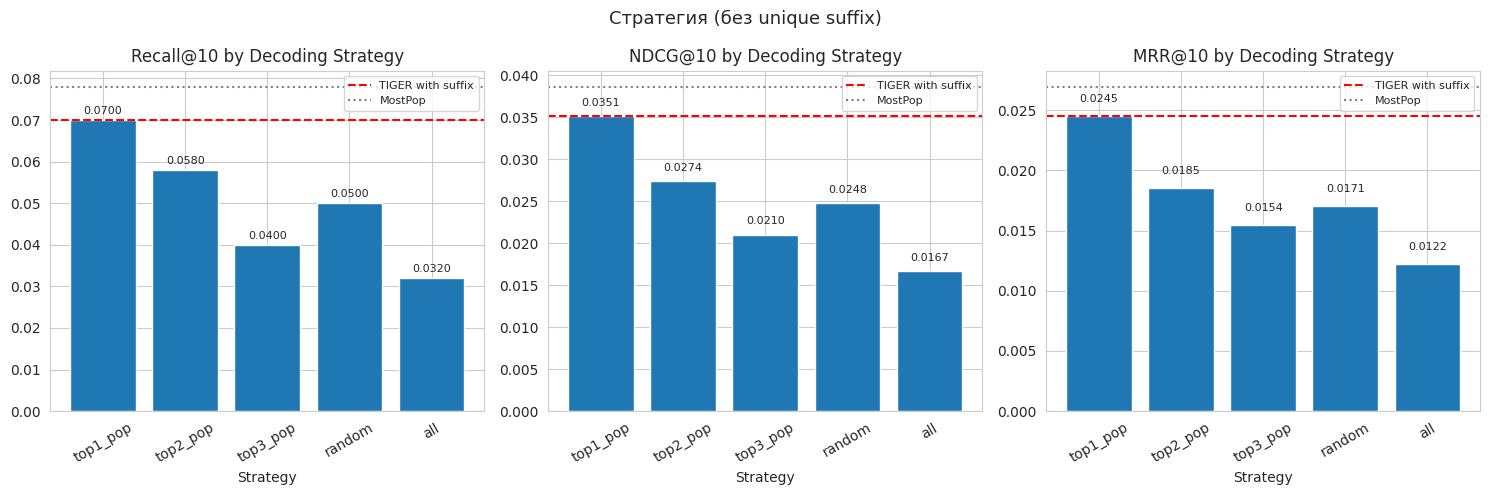

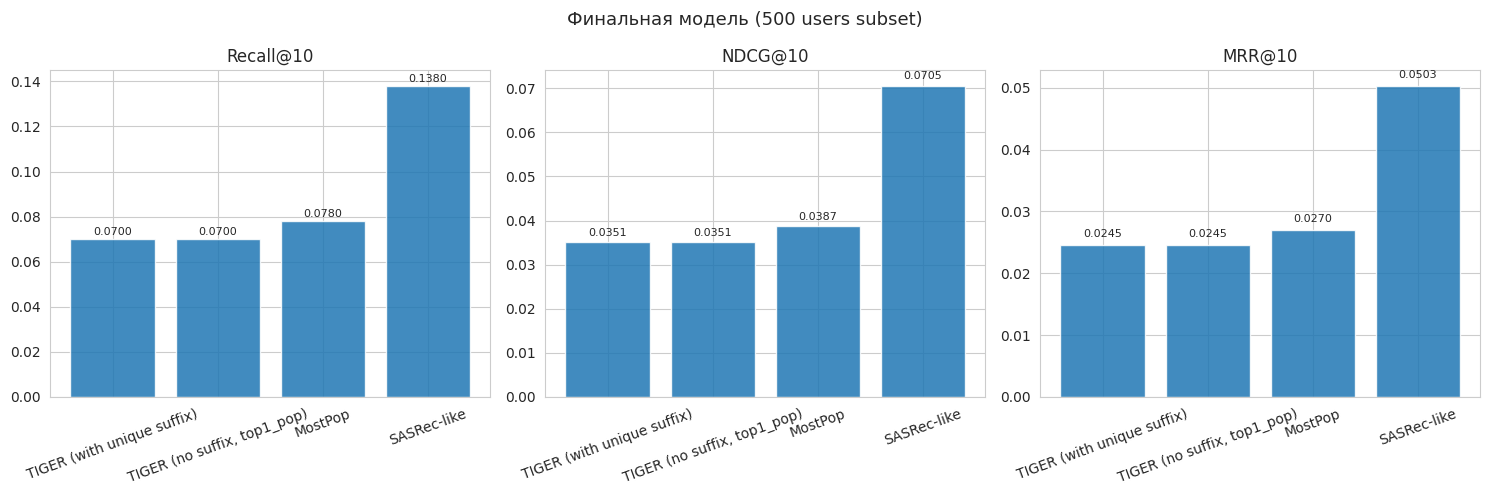

In [42]:
# График стратегии декодинга
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ["Recall@10", "NDCG@10", "MRR@10"]):
    bars = ax.bar(
        decoding_table["strategy"],
        decoding_table[metric]
    )
    ax.axhline(
        y=suffix_metrics.loc["score", metric],
        color="red", linestyle="--", linewidth=1.5,
        label="TIGER with suffix"
    )
    ax.axhline(
        y=most_pop_metrics_subset.loc["score", metric],
        color="gray", linestyle=":", linewidth=1.5,
        label="MostPop"
    )
    ax.set_title(f"{metric} by Decoding Strategy")
    ax.set_xlabel("Strategy")
    ax.tick_params(axis="x", rotation=30)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=8
        )
    ax.legend(fontsize=8)

plt.suptitle("Стратегия (без unique suffix)", fontsize=13)
plt.tight_layout()
plt.show()

# График финального сравнения всех моделей 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ["Recall@10", "NDCG@10", "MRR@10"]):
    alphas = [1.0, 0.5, 1.0, 1.0]
    bars = ax.bar(
        suffix_comparison.index,
        suffix_comparison[metric],
        alpha=0.85
    )
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=8
        )

plt.suptitle("Финальная модель (500 users subset)", fontsize=13)
plt.tight_layout()
plt.show()

Отчет по работе:
1. Чувствительность к стратегии декодинга (без unique suffix):
   top1_pop(0.070) > top2_pop(0.058) > random(0.050) > top3_pop(0.040) > all(0.032)

Разброс между лучшей и худшей стратегией — более чем в 2 раза. top1_pop оптимальна выбор одного наиболее популярного айтема из bucket максимизирует точность. Добавление менее популярных кандидатов (top2, top3) снижает метрики, и лишние айтемы вытесняют релевантные из других beam-гипотез.

Даже random (0.050) превосходит top3_pop (0.040), а значит популярность третьего айтема внутри bucket практически не коррелирует с релевантностью.

3. Unique suffix vs без суффикса:
   TIGER без суффикса (top1_pop): Recall@10 = 0.070
   TIGER с unique suffix: Recall@10 = 0.064
   
Вариант без суффикса оказался лучше. Основная причина заключается в том, что модель обучалась генерировать 4 токена, а sid_to_items_unique требует точного совпадения 5-токенного ключа. Без суффикса модель попадает в существующий bucket и извлекает популярный айтем через top1_pop.
Получается, что без суффикса TIGER основывается преимущественно на семантике, с суффиксом запоминает конкретные item_id, что значительно сложнее.

4. Итоговое сравнение всех моделей (500 пользователей):

SASRec превосходит лучший вариант TIGER в 2 раза. TIGER проигрывает даже MostPop на 11%, что связано с качеством RQ-VAE (collision rate около 30%,то есть треть айтемов не имеют уникального semantic id и модель видит неоднозначные цели обучения). Плюс ошибка в первом из 4 токенов делает весь сгенерированный sid неподходящим и  модель схлопывается в популярные sid, что снижает персонализацию предсказаний.